# Analysis of FVA vs MFA Confidence intervals

## Interpretation of metrics

### 1. Consistency Score
- *the fraction of reactions where FVA prediction is consistent with MFA*
- binary (overlaps or not)
$$C = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(Range_{MFA,i} \cap Range_{FVA,i})$$

### 2. Range Precision
- *the ratio of uncertainty of flux bounds*
- if comparing $\frac{FVA}{MFA}$, this will tell the FVA is X times more uncertain
$$R_i = \frac{UB_{FVA,i} - LB_{FVA,i}}{UB_{MFA,i} - LB_{MFA,i}}$$

### 3. Normalized Euclidean Distance
- *the aggregate distance from the MFA mean flux to the *nearest feasible bound* of the FVA*
- lower is better
$$D = \sum_{i=1}^{N} \min_{v \in [LB_{FVA}, UB_{FVA}]} (v - \mu_{MFA, i})^2$$

### 4. Jaccard Index 
- *a geometric measure of how well the two uncertainty ranges align*
- higher is better.**J = 1.0:** Perfect alignment of uncertainty.
$$J_i = \frac{\text{width}(Range_{MFA,i} \cap Range_{FVA,i})}{\text{width}(Range_{MFA,i} \cup Range_{FVA,i})}$$


In [15]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Packages
import os
import sys
import pandas as pd 
import cobra
import numpy as np

# Directories
ROOT_DIR = os.path.abspath('..')

if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
mfa_path = os.path.join(ROOT_DIR, 'data', 'experimental','crown_fluxomics_final.csv')
cobra_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20260119_9814','iML1515_GEM_cobra_fva_results.csv')
pre_tuned_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20260119_9814','iML1515_GEM_pre_tuning_fva_results.csv')
tuned_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20260119_9814','iML1515_GEM_fva_results.csv')

In [17]:
from kinGEMs.fluxomics_validation import create_net_FVA_dataframe

pre_tuned_net_fva_df = create_net_FVA_dataframe(pre_tuned_fva_path)
cobra_net_fva_df = create_net_FVA_dataframe(cobra_fva_path)
tuned_net_fva_df = create_net_FVA_dataframe(tuned_fva_path)

Irreversible model FVA dataframe has 3375 rows
Net FVA dataframe has 2712 rows
Irreversible model FVA dataframe has 2712 rows
Net FVA dataframe has 2712 rows
Irreversible model FVA dataframe has 3375 rows
Net FVA dataframe has 2712 rows


In [18]:
from kinGEMs.fluxomics_validation import create_fva_comparison_dataframe

df_tuned_fva = create_fva_comparison_dataframe(
    tuned_net_fva_df,
    mfa_path,
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)

df_cobra_fva = create_fva_comparison_dataframe(
    cobra_net_fva_df,
    mfa_path,
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)

df_pre_tuned_fva = create_fva_comparison_dataframe(
    pre_tuned_net_fva_df,
    mfa_path,
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)


Loaded 2712 FVA flux results
Loaded 46 MFA flux measurements
Merged dataframe has 2712 rows
Matched reactions: 46
Unmatched reactions: 2666

Loaded 2712 FVA flux results
Loaded 46 MFA flux measurements
Merged dataframe has 2712 rows
Matched reactions: 46
Unmatched reactions: 2666

Loaded 2712 FVA flux results
Loaded 46 MFA flux measurements
Merged dataframe has 2712 rows
Matched reactions: 46
Unmatched reactions: 2666



In [19]:
from kinGEMs.fluxomics_validation import (calculate_consistency_score, 
                                        calculate_range_precision_ratio, 
                                        calculate_normalized_euclidean_dist, 
                                        calculate_jaccard_index)

print(f"COBRA FVA")
consistency_score = calculate_consistency_score(df_cobra_fva)
range_precision_ratio = calculate_range_precision_ratio(df_cobra_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_cobra_fva)
jaccard_index_cobra, jaccard_df_cobra, zero_overlaps_cobra = calculate_jaccard_index(df_cobra_fva)

print(f"\nPre-tuned FVA")
consistency_score = calculate_consistency_score(df_pre_tuned_fva)
range_precision_ratio = calculate_range_precision_ratio(df_pre_tuned_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_pre_tuned_fva)
jaccard_index_pre, jaccard_df_pre, zero_overlaps_pre = calculate_jaccard_index(df_pre_tuned_fva)


print(f"\nTuned FVA")
consistency_score = calculate_consistency_score(df_tuned_fva)
range_precision_ratio = calculate_range_precision_ratio(df_tuned_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_tuned_fva)
jaccard_index_tuned, jaccard_df_tuned, zero_overlaps_tuned = calculate_jaccard_index(df_tuned_fva)

COBRA FVA

Consistency Score Analysis
   Evaluated 46 reactions
   Consistent reactions: 37
   Consistency Score: 0.8043

Range Precision Analysis
   Evaluated 46 reactions
   Median FVA width: 22.9585
   Median MFA width: 0.1784
   Median Precision Ratio: 157.3023

Euclidean Distance Analysis
   Evaluated 46 reactions
   Reactions with mean outside FVA range: 9
   Sum of Squared Distances (SSD): 61.3884

Jaccard Index Analysis
   Evaluated 46 reactions
   Perfect overlaps (J=1.0): 0
   Zero overlaps (J=0.0): 9
   Mean Jaccard Index: 0.0083

Pre-tuned FVA

Consistency Score Analysis
   Evaluated 46 reactions
   Consistent reactions: 22
   Consistency Score: 0.4783

Range Precision Analysis
   Evaluated 46 reactions
   Median FVA width: 1.4295
   Median MFA width: 0.1784
   Median Precision Ratio: 4.0499

Euclidean Distance Analysis
   Evaluated 46 reactions
   Reactions with mean outside FVA range: 26
   Sum of Squared Distances (SSD): 467.1264

Jaccard Index Analysis
   Evaluated 46 r

Splitting visualization into 2 plots for readability.


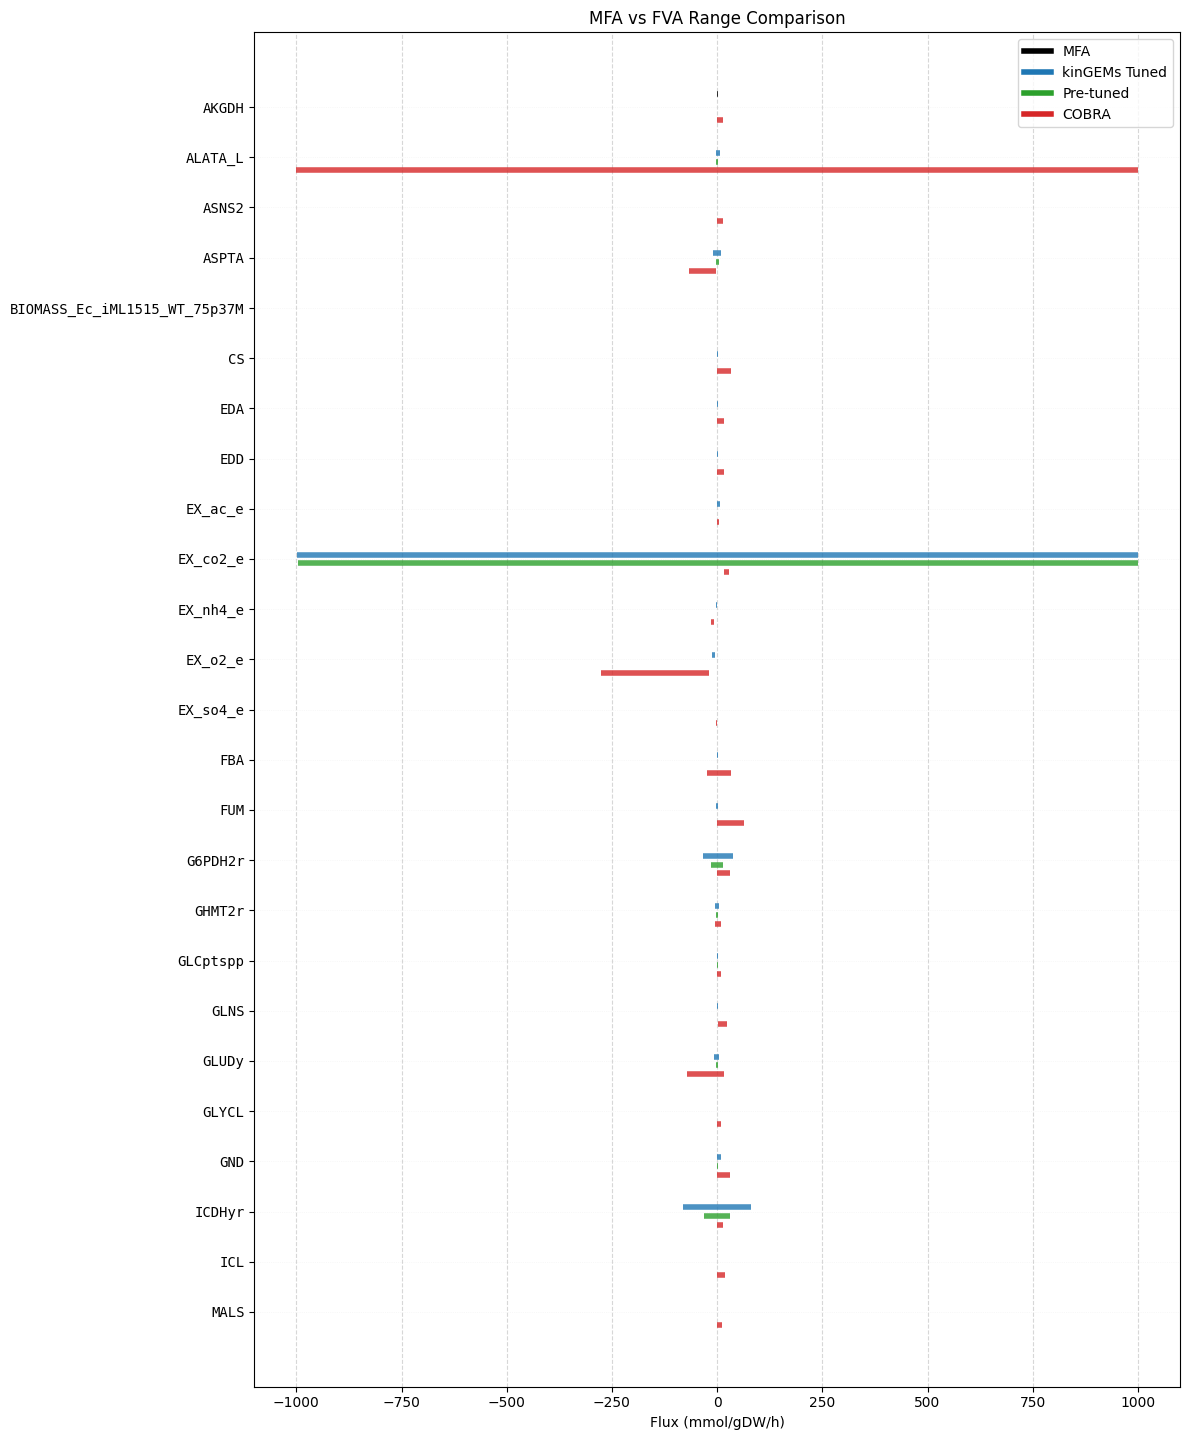

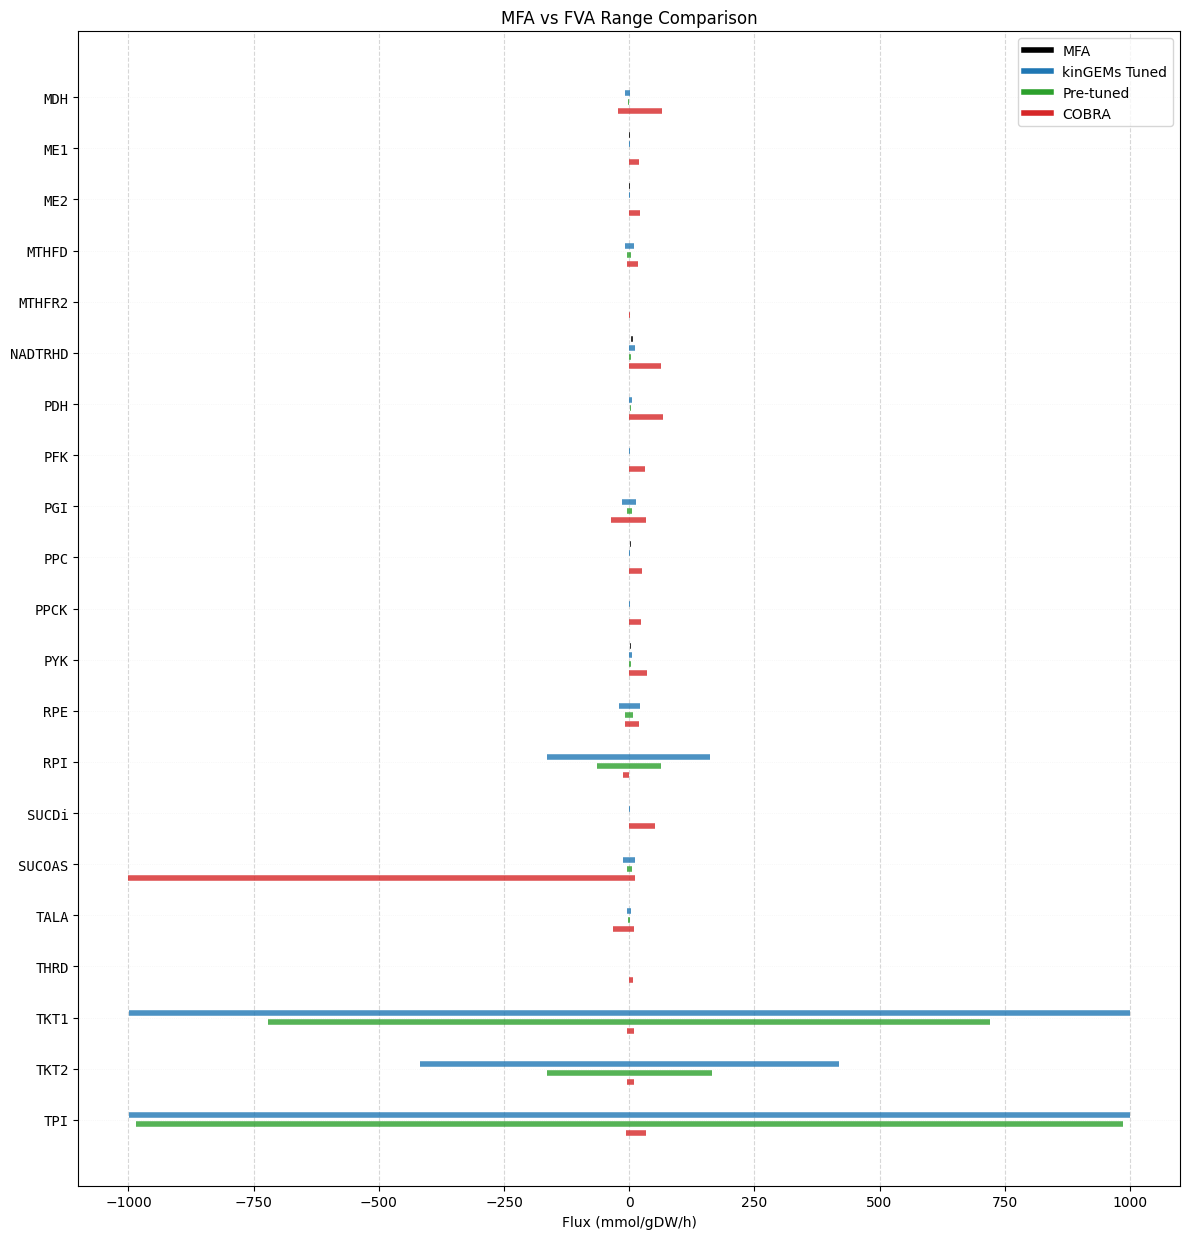

In [20]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison

plot_fva_mfa_comparison({'kinGEMs Tuned': df_tuned_fva, 'Pre-tuned': df_pre_tuned_fva, 'COBRA': df_cobra_fva})

Splitting visualization into 2 plots.


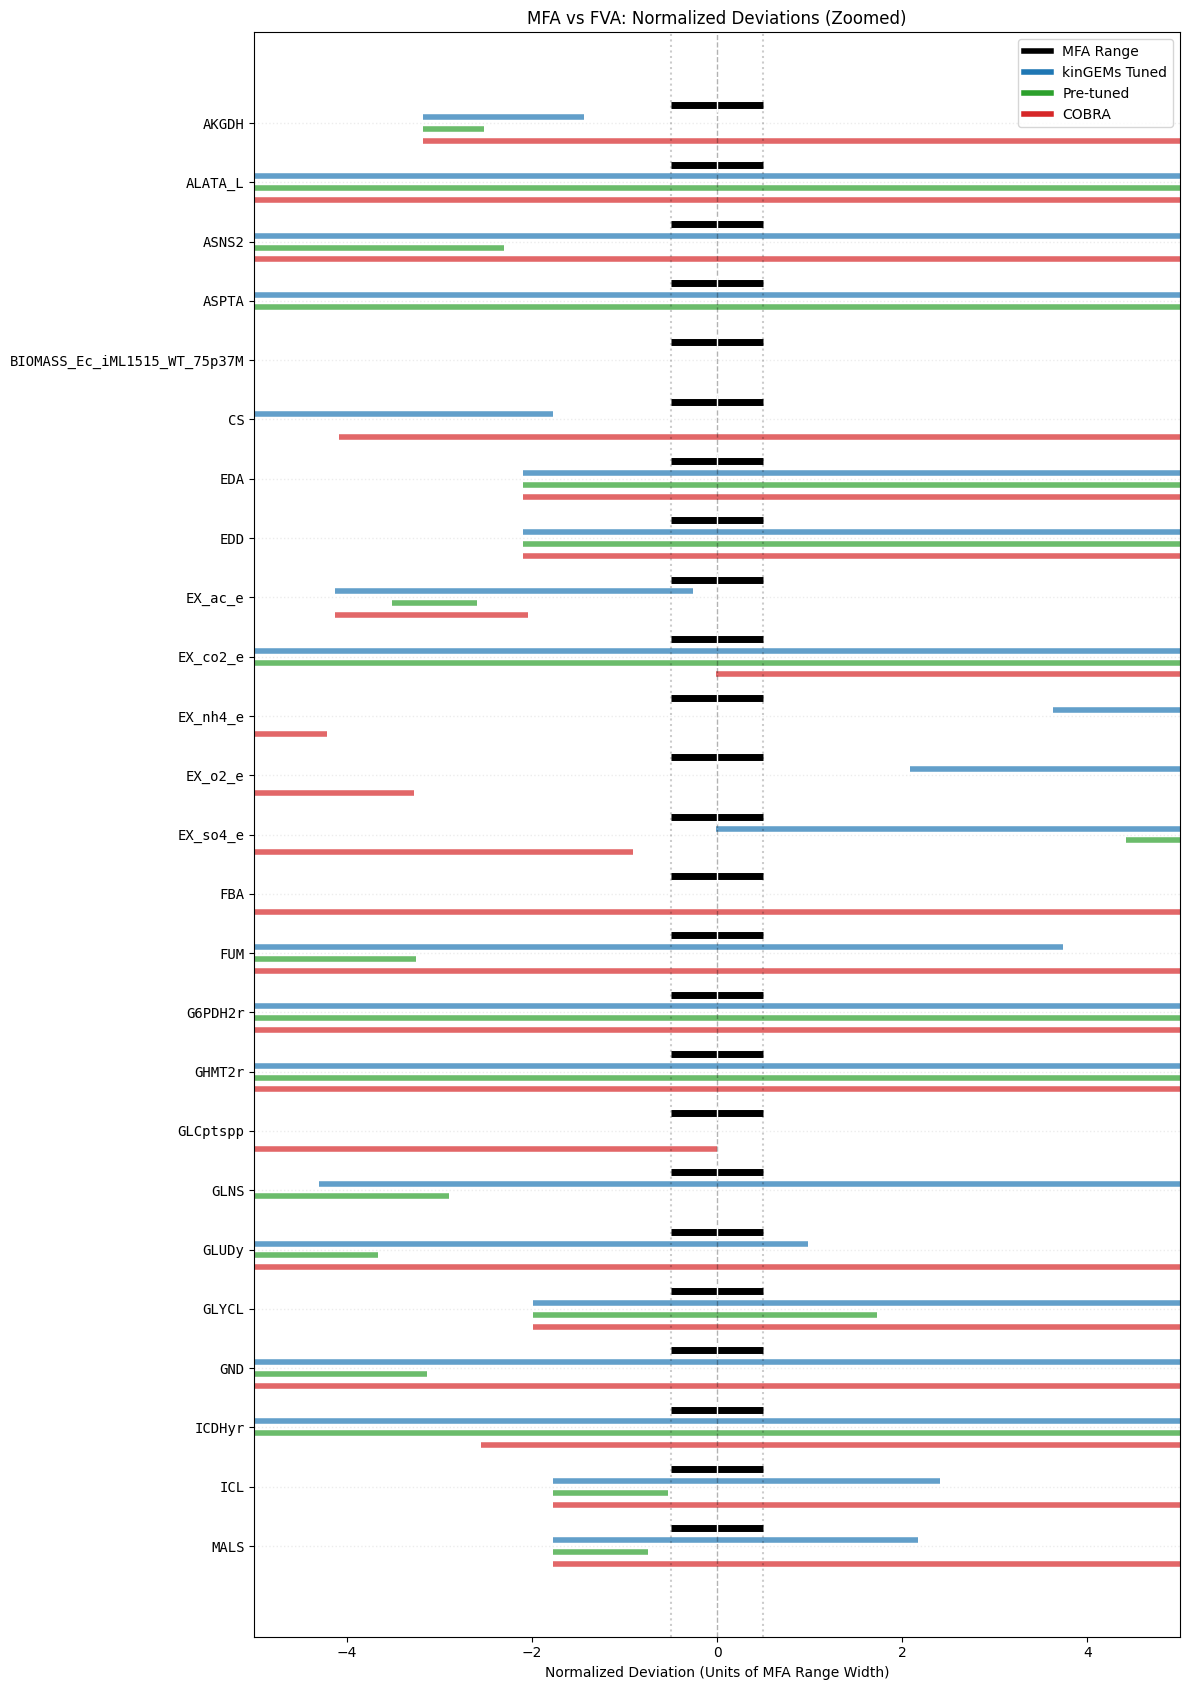

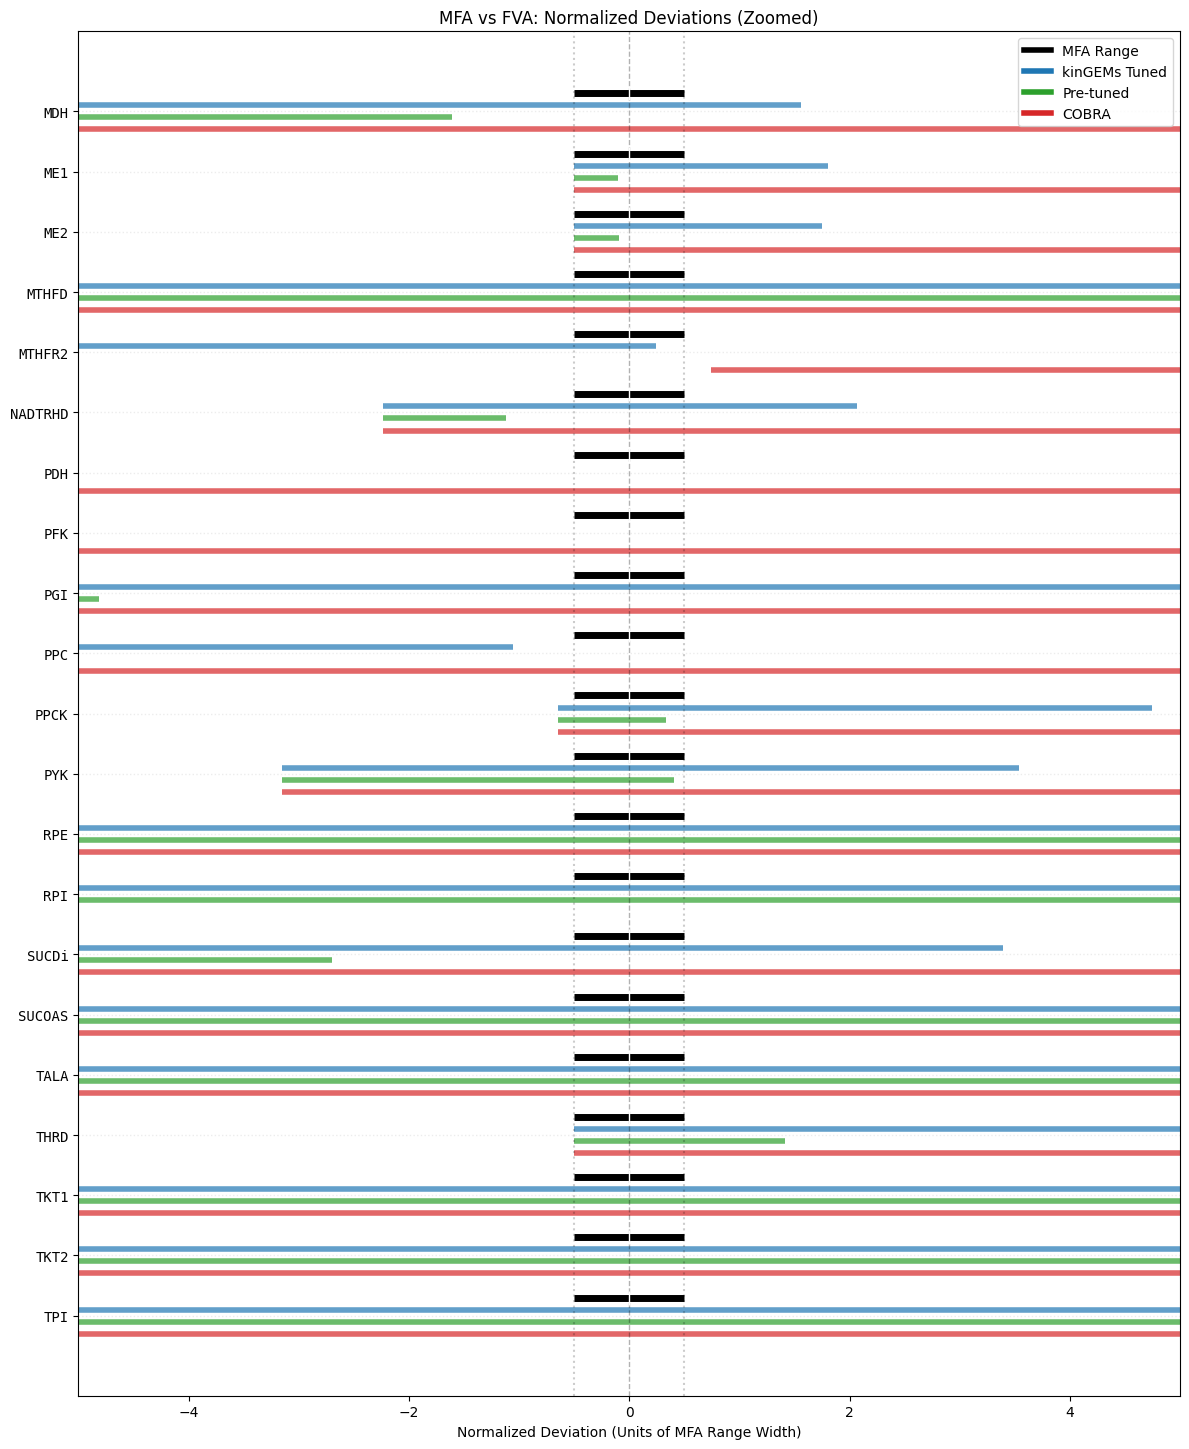

In [21]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison_normalized

plot_fva_mfa_comparison_normalized({'kinGEMs Tuned': df_tuned_fva, 'Pre-tuned': df_pre_tuned_fva, 'COBRA': df_cobra_fva})

## Plotting Jaccard Indices

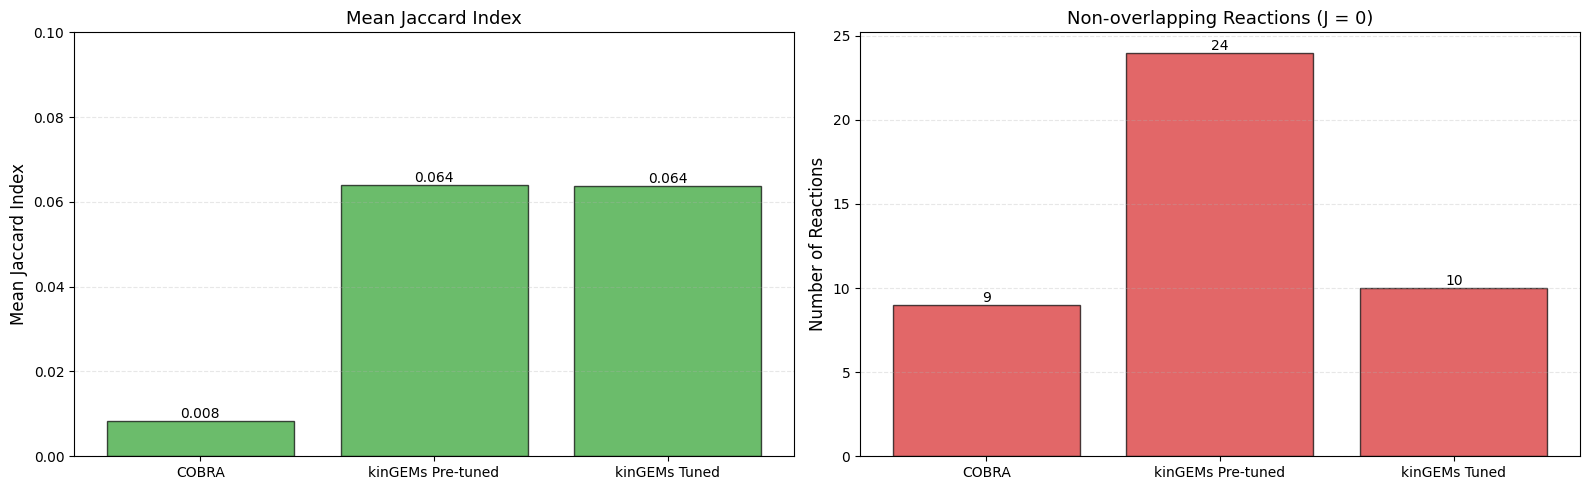

In [22]:
from kinGEMs.fluxomics_validation import plot_jaccard_index_comparison

list_jaccard_indices = [jaccard_index_cobra, jaccard_index_pre, jaccard_index_tuned]
list_zero_overlaps = [zero_overlaps_cobra, zero_overlaps_pre, zero_overlaps_tuned]
model_names = ['COBRA', 'kinGEMs Pre-tuned', 'kinGEMs Tuned']
plot_jaccard_index_comparison(list_jaccard_indices, list_zero_overlaps, model_names)

## Trimming to the rxns with the highest Jaccard Index

In [23]:
# Sort jaccard values in descending order
jaccard_sorted = jaccard_df_cobra.sort_values('jaccard', ascending=False)

# top 15 reaction IDs
top_rxn_ids = jaccard_sorted.head(15)['rxn_id'].tolist()

print("Top 15 reactions by Jaccard Index:")
print(jaccard_sorted.head(15))

# Filter dfs to top jaccard reactions
df_tuned_fva_top = df_tuned_fva[df_tuned_fva['rxn_id'].isin(top_rxn_ids)]
df_pre_tuned_fva_top = df_pre_tuned_fva[df_pre_tuned_fva['rxn_id'].isin(top_rxn_ids)]
df_cobra_fva_top = df_cobra_fva[df_cobra_fva['rxn_id'].isin(top_rxn_ids)]

Top 15 reactions by Jaccard Index:
      rxn_id   jaccard
14  EX_co2_e  0.046518
23   NADTRHD  0.039093
4        ME1  0.035279
28       ME2  0.031338
2     ICDHyr  0.024293
7        PYK  0.024194
26     AKGDH  0.020472
37       PDH  0.017136
22       PPC  0.013852
25      MALS  0.012053
3       PPCK  0.010437
34     GLUDy  0.008452
1         CS  0.008286
20       ICL  0.007732
30      TKT2  0.007202


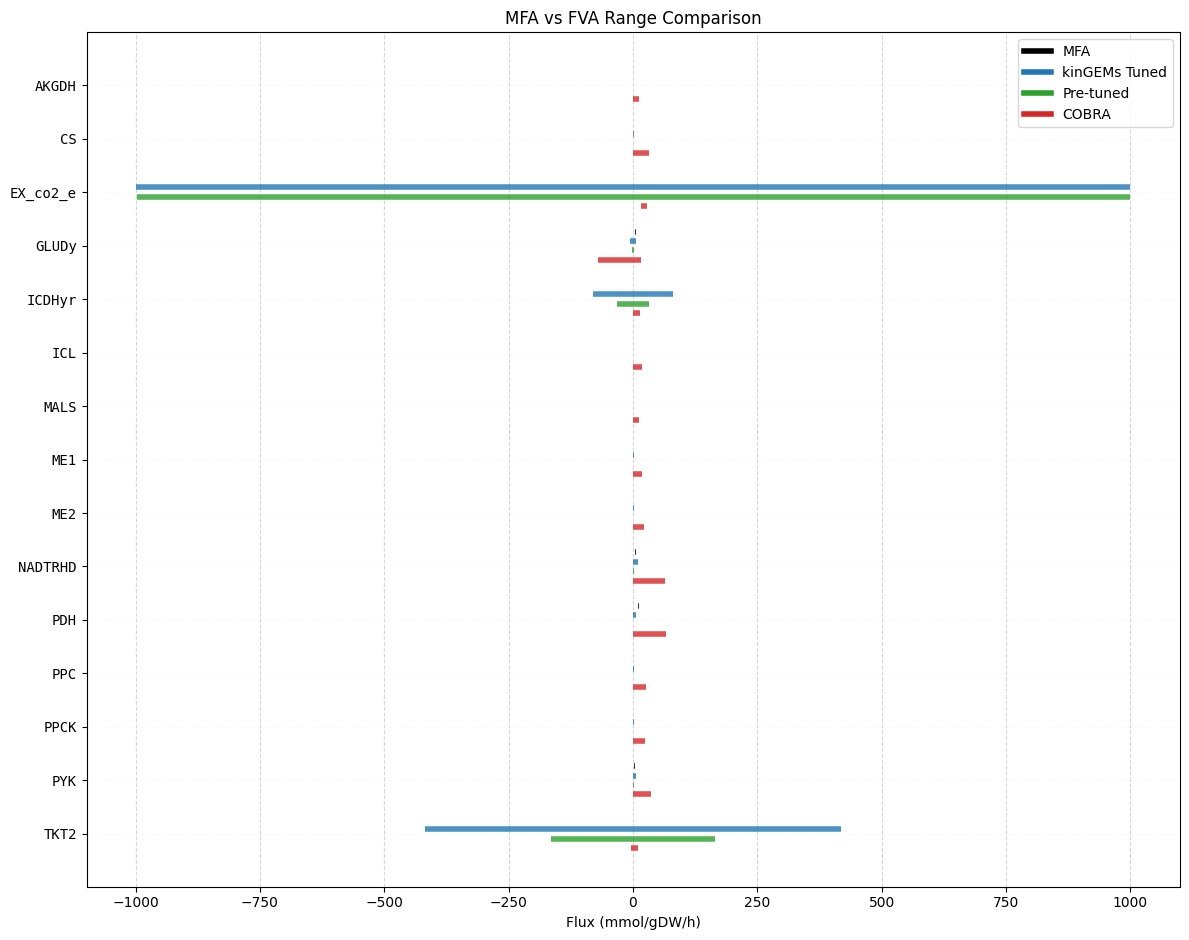

In [24]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison

plot_fva_mfa_comparison({'kinGEMs Tuned': df_tuned_fva_top, 'Pre-tuned': df_pre_tuned_fva_top, 'COBRA': df_cobra_fva_top})

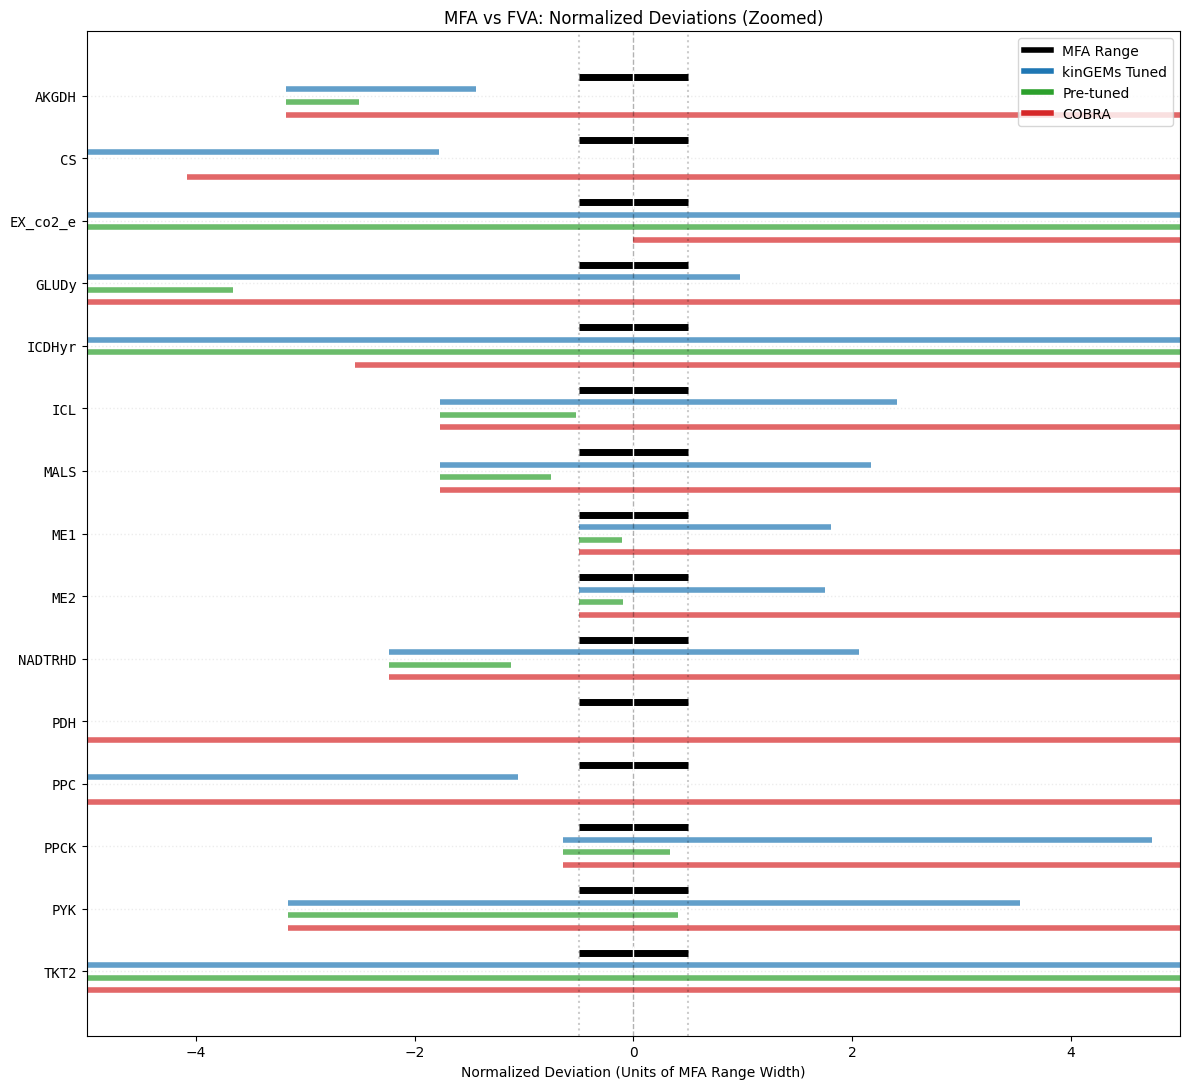

In [25]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison_normalized

plot_fva_mfa_comparison_normalized({'kinGEMs Tuned': df_tuned_fva_top, 'Pre-tuned': df_pre_tuned_fva_top, 'COBRA': df_cobra_fva_top})

## Trimming to the rxns with improved overlap

Cases were kinGEMs Tuned (blue bars) align with MFA (black bars). This shows the 

In [32]:
selected_reactions = ['EX_ac_e', 'PPC', 'NADTRHD', 'GND']
df_select_tuned = df_tuned_fva[df_tuned_fva['rxn_id'].isin(selected_reactions)]
df_select_pre = df_pre_tuned_fva[df_pre_tuned_fva['rxn_id'].isin(selected_reactions)]
df_select_cobra = df_cobra_fva[df_cobra_fva['rxn_id'].isin(selected_reactions)]

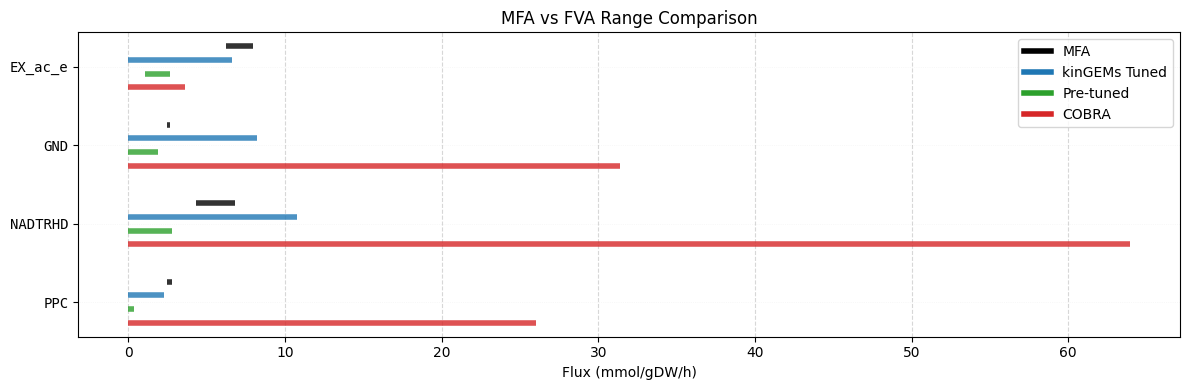

In [33]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison

plot_fva_mfa_comparison({'kinGEMs Tuned': df_select_tuned, 'Pre-tuned': df_select_pre, 'COBRA': df_select_cobra})

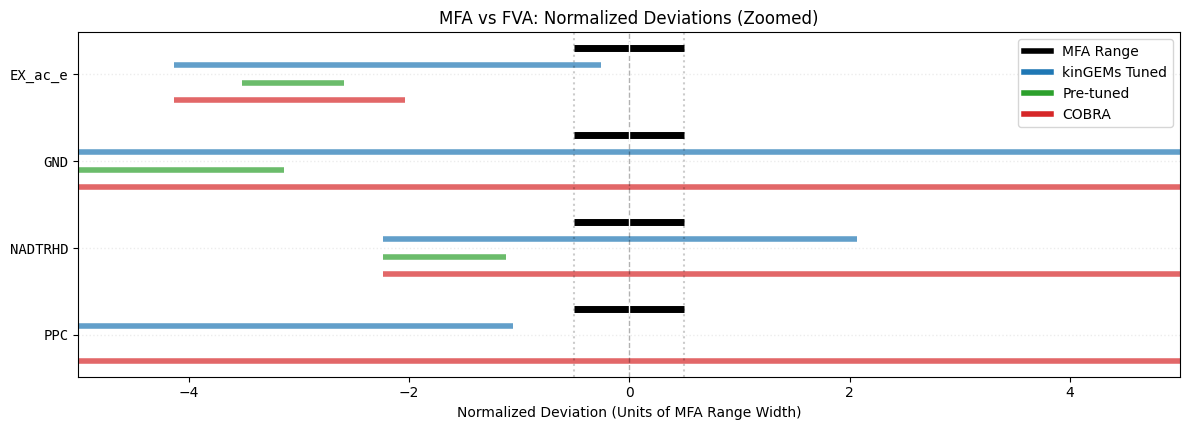

In [34]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison_normalized

plot_fva_mfa_comparison_normalized({'kinGEMs Tuned': df_select_tuned, 'Pre-tuned': df_select_pre, 'COBRA': df_select_cobra})